# k-means clusering implemented
I recently watched *StatQuest: K-Means Clustering (https://www.youtube.com/watch?v=4b5d3muPQmA)* on YouTube for uni and decided to implement k-means myself in order to understand it better for my upcoming exam.

In [158]:
import math
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

In [159]:
def calculate_distance(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    return math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

In [160]:
def set_centers(k, X):
    centers = []
    for i in range(k):
            j = np.random.randint(0, 500)
            while (X[j, 0], X[j, 1]) in centers:
                  j = np.random.randint(0, 500)
            centers.append((X[j, 0], X[j, 1]))
    return np.array(centers)


In [161]:
def k_means(k, X):
    centers = set_centers(k, X)
    y = []
    #computes which points belong to which cluster
    for i in range(len(X[:, 0])):
        min_distance = float("inf")
        cur_center = None
        for j in range(len(centers)):
            d = calculate_distance(centers[j], (X[i, 0], X[i, 1]))
            if d <= min_distance:
                min_distance = d
                cur_center = j
        y.append(cur_center)

    return np.array(y), centers

In [162]:
X, y = make_classification(
    n_samples=500, 
    n_features=2,           
    n_informative=2, 
    n_redundant=0, 
    n_classes=3,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=1123344,
)

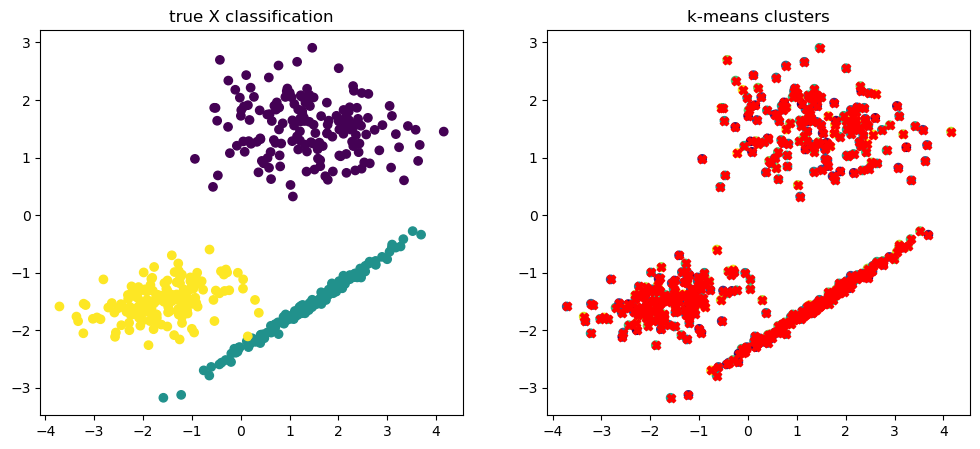

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].set_title("true X classification")
ax[0].scatter(X[:, 0], X[:, 1], c=y)


cy, centers = k_means(3, X)

ax[1].set_title("k-means clusters")
ax[1].scatter(X[:, 0], X[:, 1], c=cy)
ax[1].scatter(centers[:, 0], centers[:, 1], color="red", marker="X")
plt.show()